# Customer Segmentation pakai RFM Analysis + K-Means Clustering

## Load data + EDA

In [51]:
import pandas as pd
import numpy as np

df = pd.read_csv('dataset/online_retail_II.csv')
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [52]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None


In [53]:
# Missing Value
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [54]:
print(df[['Quantity', 'Price']].describe())

           Quantity         Price
count  1.067371e+06  1.067371e+06
mean   9.938898e+00  4.649388e+00
std    1.727058e+02  1.235531e+02
min   -8.099500e+04 -5.359436e+04
25%    1.000000e+00  1.250000e+00
50%    3.000000e+00  2.100000e+00
75%    1.000000e+01  4.150000e+00
max    8.099500e+04  3.897000e+04


## Data Cleaning

In [55]:
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print(f"\nJumlah transaksi cancelled: {len(cancelled)} baris")
print(cancelled[['Invoice', 'Quantity', 'Price', 'Customer ID']].head())


Jumlah transaksi cancelled: 19494 baris
     Invoice  Quantity  Price  Customer ID
178  C489449       -12   2.95      16321.0
179  C489449        -6   1.65      16321.0
180  C489449        -4   4.25      16321.0
181  C489449        -6   2.10      16321.0
182  C489449       -12   2.95      16321.0


In [56]:
df_clean = df.copy()

# Buang Customer ID
df_clean = df_clean.dropna(subset=['Customer ID'])
print(f"Setelah hapus customer ID kosong : {len(df_clean)} baris")

# Buang transaksi cancelled
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f"Setelah hapus transaksi cancelled : {len(df_clean)} baris")

# Buang Quantity <= 0 atau Price <=0
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"Setelah hapus Qty/Price tidak valid : {len(df_clean)} baris")

Setelah hapus customer ID kosong : 824364 baris
Setelah hapus transaksi cancelled : 805620 baris
Setelah hapus Qty/Price tidak valid : 805549 baris


In [57]:
# InoviceData dari teks -> dateTime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# TotalPrice = nilai uang per baris item
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

print(df_clean.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
TotalPrice            float64
dtype: object


In [58]:
# Ringkasan hasil cleaning + verifikasi
print("=== Ringkasan Cleaning ===")
print(f"Baris Awal      : {len(df):,}")
print(f"Baris bersih    : {len(df_clean):,}")
print(f"Dibuang         : {len(df) - len(df_clean):,}")
print(f"\nCustomer unik : {df_clean['Customer ID'].nunique():,}")
print(f"Rentang tanggal : {df_clean['InvoiceDate'].min()} s/d {df_clean['InvoiceDate'].max()}")


=== Ringkasan Cleaning ===
Baris Awal      : 1,067,371
Baris bersih    : 805,549
Dibuang         : 261,822

Customer unik : 5,878
Rentang tanggal : 2009-12-01 07:45:00 s/d 2011-12-09 12:50:00


## Hitung RFM per customer

In [59]:
# Tentukan snapshot date (anchor Recency)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

Snapshot date: 2011-12-10 12:50:00


In [60]:
# Recency
recency = df_clean.groupby('Customer ID')['InvoiceDate'].max()
recency = (snapshot_date - recency).dt.days
recency = recency.reset_index()
recency.columns = ['Customer ID', 'Recency']

In [61]:
# Frequency
frequency = df_clean.groupby('Customer ID')['Invoice'].nunique()
frequency = frequency.reset_index()
frequency.columns = ['Customer ID', 'Frequency']

In [62]:
# Monetary
monetary = df_clean.groupby('Customer ID')['TotalPrice'].sum()
monetary = monetary.reset_index()
monetary.columns = ['Customer ID', 'Monetary']

In [63]:
# Gabung jadi 1 DateFrame RFM
rfm = recency.merge(frequency, on='Customer ID').merge(monetary, on='Customer ID')
print(rfm.head())
print(f"\nJumlah Customer di RFM: {len(rfm)}")
print(rfm.describe())

   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   5633.32
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40

Jumlah Customer di RFM: 5878
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000


In [64]:
# Spot check (validasi logika)
cid = rfm['Customer ID'].iloc[0]
sub = df_clean[df_clean['Customer ID'] == cid]
print(f"Customer {cid}:")
print(f"Invoice Unik = {sub['Invoice'].nunique()} (harus = Frequency)")
print(f"Total belanja = {sub['TotalPrice'].sum():.2f} (harus = Monetary)")
print(f"Belanja terakhir = {sub['InvoiceDate'].max().date()}")

Customer 12346.0:
Invoice Unik = 12 (harus = Frequency)
Total belanja = 77556.46 (harus = Monetary)
Belanja terakhir = 2011-01-18


## Preprocessing

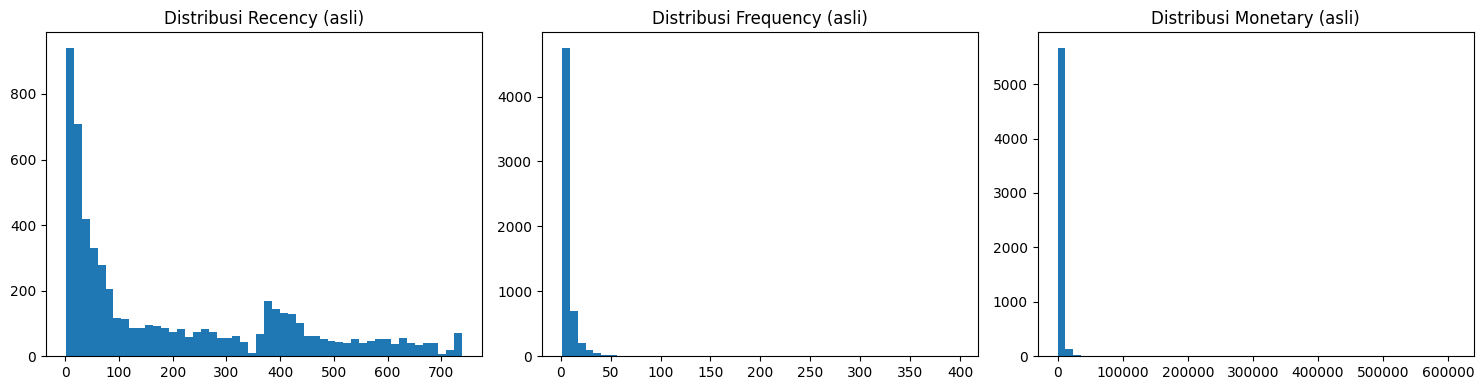

In [ ]:
# Liat distribusi asli (bukti visual)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    ax.hist(rfm[col], bins=50)
    ax.set_title(f'Distribusi {col} (asli)')
plt.tight_layout()
plt.show()

In [68]:
# Log Transform
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log)
print(rfm_log.describe())

           Recency    Frequency     Monetary
count  5878.000000  5878.000000  5878.000000
mean      4.406951     1.202239     6.833841
std       1.636277     1.028614     1.391568
min       0.000000     0.000000     1.081805
25%       3.258097     0.000000     5.854391
50%       4.564348     1.098612     6.801188
75%       5.940171     1.945910     7.743742
max       6.605298     5.986452    13.319281


In [69]:
# Scaling dengan StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

       Recency  Frequency  Monetary
count  5878.00    5878.00   5878.00
mean      0.00      -0.00      0.00
std       1.00       1.00      1.00
min      -2.69      -1.17     -4.13
25%      -0.70      -1.17     -0.70
50%       0.10      -0.10     -0.02
75%       0.94       0.72      0.65
max       1.34       4.65      4.66


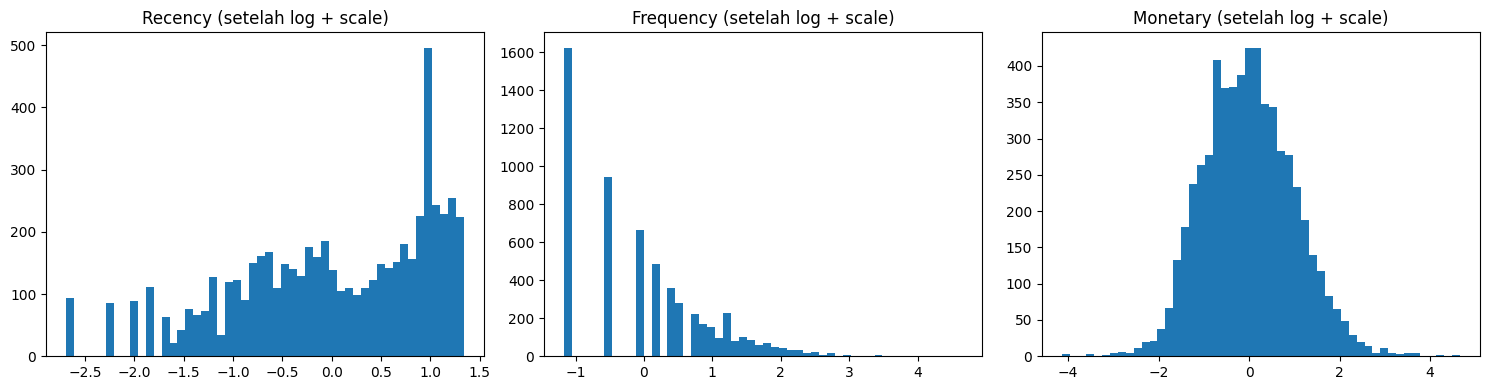

In [72]:
# Verifikasi hasil preprocessing
print(rfm_scaled.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    ax.hist(rfm_scaled[col], bins=50)
    ax.set_title(f'{col} (setelah log + scale)')
plt.tight_layout()
plt.show()